In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import torch
import torchvision.transforms as transforms

from PIL import Image

from ml.config import *
from ml.models.fusion_model import FusionModel

print("=" * 70)
print("FusionNet Streamlit Deployment")
print("=" * 70)
print("Project Root :", PROJECT_ROOT)
print("Device :", DEVICE)

PROJECT_ROOT : C:\Users\hp\Documents\Anemia_Fusion_Net_project
TRAIN_CSV    : C:\Users\hp\Documents\Anemia_Fusion_Net_project\data\processed\train.csv
VAL_CSV      : C:\Users\hp\Documents\Anemia_Fusion_Net_project\data\processed\valid.csv
IMAGE_DIR    : C:\Users\hp\Documents\Anemia_Fusion_Net_project\data\eye_image
Device       : cpu
FusionNet Streamlit Deployment
Project Root : C:\Users\hp\Documents\Anemia_Fusion_Net_project
Device : cpu


In [2]:
model = FusionModel().to(DEVICE)

model.load_state_dict(
    torch.load(
        MODEL_DIR / "fusion_best.pth",
        map_location=DEVICE
    )
)

model.eval()

print("=" * 70)
print("FusionNet Loaded Successfully")
print("=" * 70)

FusionNet Loaded Successfully


In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image Transform Ready")

Image Transform Ready


In [4]:
sample_image = PROJECT_ROOT / "data" / "eye_image" / "India" / "4" / "20200124_160522.jpg"

image = Image.open(sample_image).convert("RGB")

image = transform(image)

image = image.unsqueeze(0)

print("Image Shape :", image.shape)

Image Shape : torch.Size([1, 3, 224, 224])


In [5]:
clinical = torch.tensor([
    [1, 13.8, 25.4, 31.2, 86.5]
], dtype=torch.float32)

geo = torch.tensor([
    [0.85]
], dtype=torch.float32)

print("Clinical Shape :", clinical.shape)
print("Geo Shape :", geo.shape)

Clinical Shape : torch.Size([1, 5])
Geo Shape : torch.Size([1, 1])


In [6]:
with torch.no_grad():

    output = model(
        image.to(DEVICE),
        clinical.to(DEVICE),
        geo.to(DEVICE)
    )

    probabilities = torch.softmax(output, dim=1)

    prediction = torch.argmax(probabilities, dim=1)

confidence = probabilities.max().item()

print("Prediction Completed")

Prediction Completed


In [7]:
label = "Anemia" if prediction.item() == 1 else "Normal"

print("=" * 70)
print("FusionNet Prediction")
print("=" * 70)
print("Prediction :", label)
print(f"Confidence : {confidence*100:.2f}%")

FusionNet Prediction
Prediction : Anemia
Confidence : 79.76%


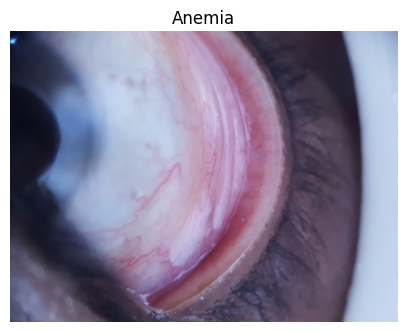

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.imshow(Image.open(sample_image))
plt.axis("off")
plt.title(label)
plt.show()

In [9]:
print("=" * 70)
print("Deployment Summary")
print("=" * 70)

print("Model :", "FusionNet")
print("Input :", "Image + Clinical + Geo")
print("Output :", label)
print("Confidence :", f"{confidence*100:.2f}%")

Deployment Summary
Model : FusionNet
Input : Image + Clinical + Geo
Output : Anemia
Confidence : 79.76%


In [10]:
print("=" * 70)
print("Notebook 15 Completed Successfully")
print("=" * 70)

print("""
✓ Fusion Model Loaded
✓ Sample Image Loaded
✓ Clinical Data Prepared
✓ Geo Data Prepared
✓ Prediction Generated

FusionNet is ready for Streamlit deployment.
""")

Notebook 15 Completed Successfully

✓ Fusion Model Loaded
✓ Sample Image Loaded
✓ Clinical Data Prepared
✓ Geo Data Prepared
✓ Prediction Generated

FusionNet is ready for Streamlit deployment.

